In [1]:
# ============================================
# CELL 1: Mount Google Drive & Setup
# ============================================

from google.colab import drive
drive.mount('/content/drive')

import os
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
import json
import random
import warnings
from collections import deque, namedtuple
warnings.filterwarnings('ignore')

PROJECT_DIR = '/content/drive/MyDrive/AccessoriesAI'
MODELS_DIR = os.path.join(PROJECT_DIR, 'trained_models')
DATA_DIR = os.path.join(PROJECT_DIR, 'data')
PLOTS_DIR = os.path.join(PROJECT_DIR, 'plots')

os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(PLOTS_DIR, exist_ok=True)

!pip install -q torch torchvision pandas scikit-learn matplotlib seaborn tqdm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Set seeds for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)

print(f"Project Dir: {PROJECT_DIR}")
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"\n✅ Setup Complete!")

Mounted at /content/drive
Project Dir: /content/drive/MyDrive/AccessoriesAI
Device: cpu

✅ Setup Complete!


Cell 2: Load All Previous Model Artifacts

In [3]:
# ============================================
# CELL 2: Load All Previous Model Artifacts (FIXED)
# ============================================

# ============ LOAD ACCESSORY DATA (Model 1) ============
acc_df = pd.read_csv(os.path.join(DATA_DIR, 'accessories_balanced.csv'))
print(f"📥 Accessory data: {len(acc_df)} items")
print(f"   Categories: {acc_df['category'].nunique()}")
print(f"   Categories: {acc_df['category'].unique().tolist()}")

# ============ LOAD DRESS DATA (Model 2) ============
dress_df = pd.read_csv(os.path.join(DATA_DIR, 'dresses_balanced.csv'))
print(f"\n📥 Dress data: {len(dress_df)} items")

# ============ LOAD ENCODERS ============
with open(os.path.join(MODELS_DIR, 'accessory_label_encoders.json'), 'r') as f:
    acc_encoders = json.load(f)

with open(os.path.join(MODELS_DIR, 'dress_label_encoders.json'), 'r') as f:
    dress_encoders = json.load(f)

# ============ LOAD FUSION SCHEMA ============
with open(os.path.join(MODELS_DIR, 'fusion_metadata_schema.json'), 'r') as f:
    fusion_schema = json.load(f)

OCCASIONS = fusion_schema.get('occasions', ['Casual', 'Formal', 'Party', 'Wedding', 'Festive/Religious', 'Sports', 'Beach', 'Date Night', 'Office', 'Interview'])
RELIGIONS = fusion_schema.get('religions', ['None', 'Buddhist', 'Hindu', 'Muslim', 'Christian', 'Other'])
GENDERS = fusion_schema.get('genders', ['Men', 'Women', 'Unisex'])
BUDGET_MIN = fusion_schema.get('budget_min', 0)
BUDGET_MAX = fusion_schema.get('budget_max', 50000)

# ============ DEFINE COMPATIBILITY RULES DIRECTLY ============
# (In case they weren't saved in fusion_metadata_schema.json)

COLOR_COMPAT = {
    'Black': ['Silver', 'Gold', 'Red', 'White', 'Pink', 'Blue', 'Multi-color'],
    'White': ['Gold', 'Silver', 'Blue', 'Red', 'Black', 'Teal', 'Multi-color'],
    'Blue': ['Silver', 'White', 'Gold', 'Teal', 'Navy Blue'],
    'Navy Blue': ['Silver', 'Gold', 'White', 'Copper', 'Red'],
    'Red': ['Gold', 'Black', 'Silver', 'White'],
    'Green': ['Gold', 'Brown', 'Copper', 'Beige'],
    'Pink': ['Silver', 'Gold', 'White', 'Rose', 'Purple'],
    'Purple': ['Silver', 'Gold', 'White', 'Pink'],
    'Yellow': ['Gold', 'Brown', 'Black', 'White'],
    'Orange': ['Gold', 'Brown', 'Copper', 'Black'],
    'Brown': ['Gold', 'Copper', 'Beige', 'Tan'],
    'Grey': ['Silver', 'Black', 'Blue', 'Metallic'],
    'Beige': ['Gold', 'Brown', 'Copper', 'White'],
    'Maroon': ['Gold', 'Silver', 'Copper', 'Black'],
    'Burgundy': ['Gold', 'Silver', 'Black', 'White'],
    'Teal': ['Silver', 'Gold', 'White', 'Blue'],
    'Gold': ['Black', 'White', 'Red', 'Navy Blue', 'Maroon'],
    'Silver': ['Black', 'Blue', 'White', 'Navy Blue', 'Purple'],
    'Copper': ['Brown', 'Green', 'Beige', 'Maroon'],
    'Metallic': ['Black', 'Grey', 'White', 'Navy Blue'],
    'Multi-color': ['Gold', 'Silver', 'Black', 'White'],
}

OCCASION_COMPAT = {
    'Casual': ['Casual'],
    'Formal': ['Formal', 'Casual'],
    'Party': ['Party', 'Casual'],
    'Wedding': ['Festive/Religious', 'Party', 'Formal'],
    'Festive/Religious': ['Festive/Religious', 'Formal'],
    'Sports': ['Sports', 'Casual'],
    'Beach': ['Casual', 'Sports'],
    'Date Night': ['Party', 'Casual', 'Formal'],
    'Office': ['Formal', 'Casual'],
    'Interview': ['Formal'],
}

SEASON_COMPAT = {
    'Summer': ['Summer', 'Spring'],
    'Winter': ['Winter', 'Fall'],
    'Spring': ['Spring', 'Summer'],
    'Fall': ['Fall', 'Winter'],
}

print(f"\n📥 Fusion schema loaded:")
print(f"   Occasions: {OCCASIONS}")
print(f"   Religions: {RELIGIONS}")
print(f"   Genders: {GENDERS}")

# ============ ACCESSORY CATEGORIES ============
ACCESSORY_CATEGORIES = acc_encoders['categories']
NUM_ACCESSORIES = len(ACCESSORY_CATEGORIES)

print(f"\n📥 Accessory categories ({NUM_ACCESSORIES}):")
for i, cat in enumerate(ACCESSORY_CATEGORIES):
    count = len(acc_df[acc_df['category'] == cat])
    print(f"   {i}: {cat} ({count} items)")

print(f"\n✅ Color compat: {len(COLOR_COMPAT)} colors defined")
print(f"✅ Occasion compat: {len(OCCASION_COMPAT)} occasions defined")
print(f"✅ Season compat: {len(SEASON_COMPAT)} seasons defined")
print(f"\n✅ All artifacts loaded!")

📥 Accessory data: 8523 items
   Categories: 12
   Categories: ['Hats & Headwear', 'Belts', 'Scarves & Shawls', 'Watches', 'Handbags & Clutches', 'Sunglasses & Eyewear', 'Necklaces & Chains', 'Earrings', 'Ties & Bowties', 'Bracelets & Bangles', 'Cufflinks', 'Rings']

📥 Dress data: 13095 items

📥 Fusion schema loaded:
   Occasions: ['Casual', 'Formal', 'Party', 'Wedding', 'Festive/Religious', 'Sports', 'Beach', 'Date Night', 'Office', 'Interview']
   Religions: ['None', 'Buddhist', 'Hindu', 'Muslim', 'Christian', 'Other']
   Genders: ['Men', 'Women', 'Unisex']

📥 Accessory categories (12):
   0: Belts (853 items)
   1: Bracelets & Bangles (151 items)
   2: Cufflinks (150 items)
   3: Earrings (416 items)
   4: Handbags & Clutches (2093 items)
   5: Hats & Headwear (293 items)
   6: Necklaces & Chains (176 items)
   7: Rings (150 items)
   8: Scarves & Shawls (363 items)
   9: Sunglasses & Eyewear (1073 items)
   10: Ties & Bowties (263 items)
   11: Watches (2542 items)

✅ Color compat: 

Cell 3: Build Accessory Wardrobe (Action Space)

In [4]:
# ============================================
# CELL 3: Build Accessory Wardrobe (Action Space)
# ============================================

# In DQN terms:
# - STATE  = 256-dim fused vector (from Model 3)
# - ACTION = selecting an accessory from the wardrobe
# - REWARD = compatibility score (how well the accessory matches)
#
# Each accessory in the wardrobe is encoded as a feature vector

def encode_accessory(acc_row):
    """Encode a single accessory as a feature vector."""
    vec = []

    # Category one-hot
    cat_vec = [0.0] * NUM_ACCESSORIES
    cat = str(acc_row.get('category', ''))
    if cat in ACCESSORY_CATEGORIES:
        cat_vec[ACCESSORY_CATEGORIES.index(cat)] = 1.0
    vec.extend(cat_vec)

    # Color one-hot
    acc_colors = acc_encoders['colors']
    color_vec = [0.0] * len(acc_colors)
    color = str(acc_row.get('mapped_color', 'Multi-color'))
    if color in acc_colors:
        color_vec[acc_colors.index(color)] = 1.0
    vec.extend(color_vec)

    # Gender one-hot
    acc_genders = acc_encoders['genders']
    gen_vec = [0.0] * len(acc_genders)
    gender = str(acc_row.get('gender', 'Unisex'))
    if gender in acc_genders:
        gen_vec[acc_genders.index(gender)] = 1.0
    vec.extend(gen_vec)

    # Season one-hot
    acc_seasons = acc_encoders['seasons']
    sea_vec = [0.0] * len(acc_seasons)
    season = str(acc_row.get('season', 'Fall'))
    if season in acc_seasons:
        sea_vec[acc_seasons.index(season)] = 1.0
    vec.extend(sea_vec)

    # Usage one-hot
    acc_usages = acc_encoders['usages']
    use_vec = [0.0] * len(acc_usages)
    usage = str(acc_row.get('mapped_usage', 'Casual'))
    if usage in acc_usages:
        use_vec[acc_usages.index(usage)] = 1.0
    vec.extend(use_vec)

    return vec

# Build wardrobe — encode ALL accessories
print("🔄 Building accessory wardrobe...")

wardrobe = []
wardrobe_metadata = []

for idx, row in acc_df.iterrows():
    vec = encode_accessory(row)
    wardrobe.append(vec)
    wardrobe_metadata.append({
        'id': row.get('id', idx),
        'category': str(row.get('category', '')),
        'color': str(row.get('mapped_color', 'Multi-color')),
        'gender': str(row.get('gender', 'Unisex')),
        'season': str(row.get('season', 'Fall')),
        'usage': str(row.get('mapped_usage', 'Casual')),
        'name': str(row.get('productDisplayName', f'Accessory_{idx}')),
    })

wardrobe_tensor = torch.tensor(wardrobe, dtype=torch.float32)
ACCESSORY_DIM = wardrobe_tensor.shape[1]
WARDROBE_SIZE = wardrobe_tensor.shape[0]

print(f"\n{'='*60}")
print(f"📦 ACCESSORY WARDROBE")
print(f"{'='*60}")
print(f"   Total accessories: {WARDROBE_SIZE}")
print(f"   Feature dimension: {ACCESSORY_DIM}")
print(f"   Tensor shape: {wardrobe_tensor.shape}")

print(f"\n   Feature breakdown:")
print(f"   Category one-hot:  {NUM_ACCESSORIES}")
print(f"   Color one-hot:     {len(acc_encoders['colors'])}")
print(f"   Gender one-hot:    {len(acc_encoders['genders'])}")
print(f"   Season one-hot:    {len(acc_encoders['seasons'])}")
print(f"   Usage one-hot:     {len(acc_encoders['usages'])}")
print(f"   Total:             {ACCESSORY_DIM}")

print(f"\n   Sample accessory: {wardrobe_metadata[0]}")
print(f"\n✅ Wardrobe built!")

🔄 Building accessory wardrobe...

📦 ACCESSORY WARDROBE
   Total accessories: 8523
   Feature dimension: 49
   Tensor shape: torch.Size([8523, 49])

   Feature breakdown:
   Category one-hot:  12
   Color one-hot:     25
   Gender one-hot:    3
   Season one-hot:    4
   Usage one-hot:     5
   Total:             49

   Sample accessory: {'id': 34797, 'category': 'Hats & Headwear', 'color': 'Grey', 'gender': 'Men', 'season': 'Summer', 'usage': 'Casual', 'name': 'Flying Machine Men Grey Hat'}

✅ Wardrobe built!


Cell 4: Define Reward Function

In [5]:
# ============================================
# CELL 4: Define Reward Function
# ============================================

def compute_reward(dress_info, accessory_info, occasion, religion, gender, budget):
    """
    Compute reward for recommending this accessory with this dress.

    Reward = weighted combination of:
    - Color compatibility (0.25)
    - Occasion match (0.25)
    - Season match (0.15)
    - Gender match (0.15)
    - Category diversity bonus (0.10)
    - Budget fit (0.10)

    Returns: float reward in range [0, 1]
    """
    reward = 0.0

    # 1. Color compatibility (0.25)
    dress_color = dress_info.get('color', 'Multi-color')
    acc_color = accessory_info.get('color', 'Multi-color')
    compatible_colors = COLOR_COMPAT.get(dress_color, [])
    if acc_color in compatible_colors:
        reward += 0.25
    elif dress_color == acc_color:
        reward += 0.15
    elif acc_color in ['Gold', 'Silver']:  # Metallics go with everything
        reward += 0.20

    # 2. Occasion match (0.25)
    acc_usage = accessory_info.get('usage', 'Casual')
    compatible_usages = OCCASION_COMPAT.get(occasion, ['Casual'])
    if acc_usage in compatible_usages:
        reward += 0.25
    elif acc_usage == 'Casual':  # Casual accessories are somewhat flexible
        reward += 0.10

    # 3. Season match (0.15)
    dress_season = dress_info.get('season', 'Fall')
    acc_season = accessory_info.get('season', 'Fall')
    compatible_seasons = SEASON_COMPAT.get(dress_season, [dress_season])
    if acc_season in compatible_seasons:
        reward += 0.15

    # 4. Gender match (0.15)
    acc_gender = accessory_info.get('gender', 'Unisex')
    if acc_gender == gender or acc_gender == 'Unisex':
        reward += 0.15
    elif gender == 'Unisex':
        reward += 0.10

    # 5. Category relevance (0.10)
    # Certain categories are more relevant for certain occasions
    category = accessory_info.get('category', '')
    occasion_category_bonus = {
        'Wedding': ['Necklaces & Chains', 'Earrings', 'Bracelets & Bangles', 'Rings'],
        'Formal': ['Watches', 'Cufflinks', 'Ties & Bowties', 'Belts'],
        'Party': ['Earrings', 'Necklaces & Chains', 'Bracelets & Bangles', 'Handbags & Clutches'],
        'Casual': ['Watches', 'Sunglasses & Eyewear', 'Belts', 'Hats & Headwear'],
        'Sports': ['Watches', 'Sunglasses & Eyewear', 'Hats & Headwear'],
        'Beach': ['Sunglasses & Eyewear', 'Hats & Headwear', 'Bracelets & Bangles'],
        'Office': ['Watches', 'Belts', 'Cufflinks', 'Ties & Bowties'],
        'Interview': ['Watches', 'Belts', 'Cufflinks'],
        'Date Night': ['Earrings', 'Necklaces & Chains', 'Watches', 'Bracelets & Bangles'],
        'Festive/Religious': ['Necklaces & Chains', 'Earrings', 'Bracelets & Bangles', 'Rings'],
    }
    if category in occasion_category_bonus.get(occasion, []):
        reward += 0.10
    else:
        reward += 0.03

    # 6. Budget consideration (0.10)
    budget_norm = min(budget / BUDGET_MAX, 1.0)
    reward += 0.10 * budget_norm

    # Add small noise
    noise = np.random.uniform(-0.02, 0.02)
    reward = np.clip(reward + noise, 0.0, 1.0)

    return round(reward, 4)

# ============ TEST REWARD FUNCTION ============
test_dress = {'color': 'Red', 'season': 'Summer'}
test_acc_good = {'color': 'Gold', 'usage': 'Formal', 'season': 'Summer', 'gender': 'Women', 'category': 'Necklaces & Chains'}
test_acc_bad = {'color': 'Green', 'usage': 'Sports', 'season': 'Winter', 'gender': 'Men', 'category': 'Hats & Headwear'}

good_reward = compute_reward(test_dress, test_acc_good, 'Wedding', 'Buddhist', 'Women', 15000)
bad_reward = compute_reward(test_dress, test_acc_bad, 'Wedding', 'Buddhist', 'Women', 15000)

print(f"📊 Reward Function Test:")
print(f"   Red Dress + Gold Necklace (Wedding): {good_reward:.4f} ← Should be HIGH")
print(f"   Red Dress + Green Sports Hat (Wedding): {bad_reward:.4f} ← Should be LOW")
print(f"\n✅ Reward function working correctly!" if good_reward > bad_reward else "\n❌ Check reward function!")

📊 Reward Function Test:
   Red Dress + Gold Necklace (Wedding): 0.9250 ← Should be HIGH
   Red Dress + Green Sports Hat (Wedding): 0.0780 ← Should be LOW

✅ Reward function working correctly!


Cell 5: Define DQN Environment

In [6]:
# ============================================
# CELL 5: Define DQN Environment
# ============================================

class AccessoryRecommendationEnv:
    """
    RL Environment for accessory recommendation.

    State:  256-dim fused vector (from Model 3) + previously selected accessories info
    Action: Select an accessory index from wardrobe
    Reward: Compatibility score
    Done:   After selecting 3 accessories (Top 3 recommendations)
    """
    def __init__(self, wardrobe_tensor, wardrobe_metadata, state_dim=256, max_recommendations=3):
        self.wardrobe = wardrobe_tensor
        self.wardrobe_metadata = wardrobe_metadata
        self.wardrobe_size = len(wardrobe_metadata)
        self.state_dim = state_dim
        self.max_recommendations = max_recommendations

        # State = fused_vector(256) + selection_history(max_rec * acc_dim) + step_count(1)
        self.acc_dim = wardrobe_tensor.shape[1]
        self.full_state_dim = state_dim + (max_recommendations * self.acc_dim) + 1

        self.reset()

    def reset(self, fused_vector=None, dress_info=None, occasion=None,
              religion=None, gender=None, budget=None):
        """Reset environment for a new recommendation session."""
        if fused_vector is None:
            self.fused_vector = np.random.randn(self.state_dim).astype(np.float32)
        else:
            self.fused_vector = fused_vector

        self.dress_info = dress_info or {}
        self.occasion = occasion or 'Casual'
        self.religion = religion or 'None'
        self.gender = gender or 'Unisex'
        self.budget = budget or 5000

        self.selected_accessories = []
        self.selected_categories = set()
        self.step_count = 0
        self.total_reward = 0

        return self._get_state()

    def _get_state(self):
        """Build full state vector."""
        # Base: fused vector
        state = list(self.fused_vector)

        # Add selected accessories history (padded)
        for i in range(self.max_recommendations):
            if i < len(self.selected_accessories):
                acc_idx = self.selected_accessories[i]
                state.extend(self.wardrobe[acc_idx].numpy().tolist())
            else:
                state.extend([0.0] * self.acc_dim)

        # Step count (normalized)
        state.append(self.step_count / self.max_recommendations)

        return np.array(state, dtype=np.float32)

    def step(self, action):
        """
        Take action (select accessory at index 'action').
        Returns: next_state, reward, done, info
        """
        acc_info = self.wardrobe_metadata[action]

        # Base reward from compatibility
        reward = compute_reward(
            self.dress_info, acc_info,
            self.occasion, self.religion, self.gender, self.budget
        )

        # Diversity bonus: reward selecting different categories
        if acc_info['category'] not in self.selected_categories:
            reward += 0.15  # Diversity bonus
        else:
            reward -= 0.20  # Penalty for duplicate category

        # Penalty for selecting same item again
        if action in self.selected_accessories:
            reward -= 0.50

        reward = np.clip(reward, 0.0, 1.0)

        # Update state
        self.selected_accessories.append(action)
        self.selected_categories.add(acc_info['category'])
        self.step_count += 1
        self.total_reward += reward

        done = (self.step_count >= self.max_recommendations)

        info = {
            'accessory': acc_info,
            'step': self.step_count,
            'cumulative_reward': self.total_reward,
        }

        next_state = self._get_state()

        return next_state, reward, done, info

    def get_action_mask(self):
        """Return mask of valid actions (exclude already selected)."""
        mask = np.ones(self.wardrobe_size, dtype=np.float32)
        for idx in self.selected_accessories:
            mask[idx] = 0.0
        return mask

# ============ TEST ENVIRONMENT ============
env = AccessoryRecommendationEnv(
    wardrobe_tensor=wardrobe_tensor,
    wardrobe_metadata=wardrobe_metadata,
    state_dim=256,
    max_recommendations=3
)

state = env.reset(
    fused_vector=np.random.randn(256).astype(np.float32),
    dress_info={'color': 'Red', 'season': 'Summer'},
    occasion='Wedding',
    religion='Buddhist',
    gender='Women',
    budget=15000
)

print(f"📊 Environment Test:")
print(f"   State dim: {len(state)} = 256 + (3 × {env.acc_dim}) + 1")
print(f"   Full state dim: {env.full_state_dim}")
print(f"   Wardrobe size: {env.wardrobe_size}")
print(f"   Max recommendations: {env.max_recommendations}")

# Take 3 random actions
for i in range(3):
    action = random.randint(0, env.wardrobe_size - 1)
    next_state, reward, done, info = env.step(action)
    print(f"\n   Step {i+1}: Selected {info['accessory']['category']} ({info['accessory']['color']})")
    print(f"   Reward: {reward:.4f} | Done: {done}")

print(f"\n✅ Environment working! Total reward: {env.total_reward:.4f}")

📊 Environment Test:
   State dim: 404 = 256 + (3 × 49) + 1
   Full state dim: 404
   Wardrobe size: 8523
   Max recommendations: 3

   Step 1: Selected Bracelets & Bangles (Metallic)
   Reward: 0.5488 | Done: False

   Step 2: Selected Ties & Bowties (Navy Blue)
   Reward: 0.4746 | Done: False

   Step 3: Selected Belts (Purple)
   Reward: 0.4727 | Done: True

✅ Environment working! Total reward: 1.4961


Cell 6: Build DQN Network

In [7]:
# ============================================
# CELL 6: Build DQN Network
# ============================================

class DuelingDQN(nn.Module):
    """
    Dueling DQN Architecture for accessory recommendation.

    Instead of directly outputting Q-values for each accessory (8400 actions),
    we use a scoring approach:
    - Network takes state → produces a query vector
    - Query vector is compared with each accessory in wardrobe
    - Score = dot product(query, accessory)

    This is scalable and handles large action spaces efficiently.
    """
    def __init__(self, state_dim, query_dim=128, accessory_dim=None):
        super(DuelingDQN, self).__init__()

        self.state_dim = state_dim
        self.query_dim = query_dim

        # ============ STATE ENCODER ============
        self.state_encoder = nn.Sequential(
            nn.Linear(state_dim, 512),
            nn.ReLU(inplace=True),
            nn.LayerNorm(512),
            nn.Dropout(0.1),
            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
            nn.LayerNorm(256),
            nn.Dropout(0.1),
        )

        # ============ VALUE STREAM (V(s)) ============
        self.value_stream = nn.Sequential(
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Linear(128, 1)
        )

        # ============ ADVANTAGE STREAM → QUERY VECTOR ============
        self.advantage_stream = nn.Sequential(
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Linear(128, query_dim)  # Output: query vector
        )

        # ============ ACCESSORY ENCODER ============
        # Project accessory features to same query_dim
        self.accessory_encoder = nn.Sequential(
            nn.Linear(accessory_dim, query_dim),
            nn.ReLU(inplace=True),
            nn.LayerNorm(query_dim),
        )

        # Initialize weights
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, state, wardrobe):
        """
        Args:
            state: [B, state_dim]
            wardrobe: [W, acc_dim] - all accessories

        Returns:
            q_values: [B, W] - Q-value for each accessory
        """
        # Encode state
        encoded = self.state_encoder(state)       # [B, 256]

        # Value stream
        value = self.value_stream(encoded)        # [B, 1]

        # Advantage stream → query vector
        query = self.advantage_stream(encoded)    # [B, query_dim]

        # Encode wardrobe
        acc_encoded = self.accessory_encoder(wardrobe)  # [W, query_dim]

        # Compute advantage as dot product: query · accessory
        # [B, query_dim] × [query_dim, W] → [B, W]
        advantage = torch.matmul(query, acc_encoded.T)

        # Dueling: Q(s,a) = V(s) + A(s,a) - mean(A(s,a))
        q_values = value + advantage - advantage.mean(dim=1, keepdim=True)

        return q_values

    def get_query_vector(self, state):
        """Get query vector for a state (for analysis/visualization)."""
        encoded = self.state_encoder(state)
        query = self.advantage_stream(encoded)
        return query

# ============ INITIALIZE ============
STATE_DIM = env.full_state_dim
QUERY_DIM = 128

policy_net = DuelingDQN(
    state_dim=STATE_DIM,
    query_dim=QUERY_DIM,
    accessory_dim=ACCESSORY_DIM
).to(device)

target_net = DuelingDQN(
    state_dim=STATE_DIM,
    query_dim=QUERY_DIM,
    accessory_dim=ACCESSORY_DIM
).to(device)

# Copy policy to target
target_net.load_state_dict(policy_net.state_dict())
target_net.eval()

total_params = sum(p.numel() for p in policy_net.parameters())
print(f"📊 DQN Model Summary:")
print(f"   State dim:     {STATE_DIM}")
print(f"   Query dim:     {QUERY_DIM}")
print(f"   Accessory dim: {ACCESSORY_DIM}")
print(f"   Wardrobe size: {WARDROBE_SIZE}")
print(f"   Total params:  {total_params:,}")
print(f"\n   Architecture:")
print(f"   State Encoder: {STATE_DIM} → 512 → 256")
print(f"   Value Stream:  256 → 128 → 1")
print(f"   Advantage:     256 → 128 → {QUERY_DIM}")
print(f"   Accessory Enc: {ACCESSORY_DIM} → {QUERY_DIM}")
print(f"   Q-values:      V(s) + query·acc - mean")
print(f"\n✅ DQN networks created (Policy + Target)!")

📊 DQN Model Summary:
   State dim:     404
   Query dim:     128
   Accessory dim: 49
   Wardrobe size: 8523
   Total params:  429,313

   Architecture:
   State Encoder: 404 → 512 → 256
   Value Stream:  256 → 128 → 1
   Advantage:     256 → 128 → 128
   Accessory Enc: 49 → 128
   Q-values:      V(s) + query·acc - mean

✅ DQN networks created (Policy + Target)!


Cell 7: Replay Buffer & Training Config

In [8]:
# ============================================
# CELL 7: Replay Buffer & Training Config
# ============================================

# ============ EXPERIENCE REPLAY BUFFER ============
Transition = namedtuple('Transition', ('state', 'action', 'reward', 'next_state', 'done'))

class ReplayBuffer:
    def __init__(self, capacity=100000):
        self.buffer = deque(maxlen=capacity)

    def push(self, *args):
        self.buffer.append(Transition(*args))

    def sample(self, batch_size):
        transitions = random.sample(self.buffer, batch_size)
        batch = Transition(*zip(*transitions))
        return batch

    def __len__(self):
        return len(self.buffer)

# ============ TRAINING HYPERPARAMETERS ============
BUFFER_SIZE = 100000
BATCH_SIZE = 128
GAMMA = 0.99           # Discount factor
EPSILON_START = 1.0     # Start exploration rate
EPSILON_END = 0.05      # Minimum exploration rate
EPSILON_DECAY = 0.9995  # Decay rate per episode
LR = 1e-4              # Learning rate
TARGET_UPDATE = 10      # Update target network every N episodes
NUM_EPISODES = 2000     # Total training episodes
WARMUP_EPISODES = 200   # Fill buffer before training

# Initialize
replay_buffer = ReplayBuffer(BUFFER_SIZE)
optimizer = optim.Adam(policy_net.parameters(), lr=LR)
criterion = nn.SmoothL1Loss()  # Huber loss

# Move wardrobe to device
wardrobe_device = wardrobe_tensor.to(device)

epsilon = EPSILON_START

print("⚙️ DQN Training Configuration:")
print(f"   Buffer Size:     {BUFFER_SIZE:,}")
print(f"   Batch Size:      {BATCH_SIZE}")
print(f"   Gamma:           {GAMMA}")
print(f"   Epsilon:         {EPSILON_START} → {EPSILON_END} (decay={EPSILON_DECAY})")
print(f"   Learning Rate:   {LR}")
print(f"   Target Update:   every {TARGET_UPDATE} episodes")
print(f"   Total Episodes:  {NUM_EPISODES}")
print(f"   Warmup:          {WARMUP_EPISODES} episodes")
print(f"   Loss:            SmoothL1 (Huber)")
print(f"\n✅ Training config ready!")

⚙️ DQN Training Configuration:
   Buffer Size:     100,000
   Batch Size:      128
   Gamma:           0.99
   Epsilon:         1.0 → 0.05 (decay=0.9995)
   Learning Rate:   0.0001
   Target Update:   every 10 episodes
   Total Episodes:  2000
   Warmup:          200 episodes
   Loss:            SmoothL1 (Huber)

✅ Training config ready!


Cell 8: Generate Training Scenarios

In [9]:
# ============================================
# CELL 8: Generate Training Scenarios
# ============================================

def generate_random_scenario():
    """Generate a random dress + user scenario for training."""
    # Random dress
    dress_row = dress_df.iloc[random.randint(0, len(dress_df)-1)]

    dress_info = {
        'color': str(dress_row.get('mapped_color', 'Multi-color')),
        'neckline': str(dress_row.get('neckline', 'Crew Neck')),
        'dress_length': str(dress_row.get('dress_length', 'Knee-length')),
        'fabric': str(dress_row.get('fabric', 'Cotton')),
        'pattern': str(dress_row.get('pattern', 'Solid')),
        'sleeve_length': str(dress_row.get('sleeve_length', 'Short Sleeve')),
        'usage': str(dress_row.get('mapped_usage', 'Casual')),
        'season': str(dress_row.get('season', 'Fall')),
    }

    # Random user context
    occasion = random.choice(OCCASIONS)
    religion = random.choice(RELIGIONS)
    gender = random.choice(GENDERS)
    budget = random.uniform(500, BUDGET_MAX)

    # Simulate Model 3 output (256-dim fused vector)
    # In production, this comes from the actual Model 3
    # For training, we create a structured vector based on dress + context
    fused_vector = np.zeros(256, dtype=np.float32)

    # Embed dress color info in first 20 dims
    dress_colors = dress_encoders['color']['classes']
    if dress_info['color'] in dress_colors:
        fused_vector[dress_colors.index(dress_info['color'])] = 1.0

    # Embed occasion in dims 20-30
    if occasion in OCCASIONS:
        fused_vector[20 + OCCASIONS.index(occasion)] = 1.0

    # Embed season in dims 30-34
    seasons_list = dress_encoders['season']['classes']
    if dress_info['season'] in seasons_list:
        fused_vector[30 + seasons_list.index(dress_info['season'])] = 1.0

    # Embed gender in dims 34-37
    if gender in GENDERS:
        fused_vector[34 + GENDERS.index(gender)] = 1.0

    # Budget in dim 37
    fused_vector[37] = budget / BUDGET_MAX

    # Add random noise to remaining dimensions (simulate CNN features)
    fused_vector[40:] = np.random.randn(216).astype(np.float32) * 0.1

    return fused_vector, dress_info, occasion, religion, gender, budget

# Test
fv, di, occ, rel, gen, bud = generate_random_scenario()
print(f"📊 Sample Scenario:")
print(f"   Dress: {di['color']} {di['pattern']} {di['fabric']} ({di['neckline']}, {di['sleeve_length']})")
print(f"   Occasion: {occ} | Religion: {rel} | Gender: {gen} | Budget: Rs.{bud:.0f}")
print(f"   Fused vector shape: {fv.shape}")
print(f"   Non-zero elements: {np.count_nonzero(fv[:40])}")
print(f"\n✅ Scenario generator ready!")

📊 Sample Scenario:
   Dress: Grey Abstract Crepe (Off-Shoulder, Sleeveless)
   Occasion: Wedding | Religion: Buddhist | Gender: Unisex | Budget: Rs.5574
   Fused vector shape: (256,)
   Non-zero elements: 5

✅ Scenario generator ready!


Cell 9: DQN Training Loop

In [10]:
# ============================================
# CELL 9: DQN Training Loop
# ============================================

from tqdm import tqdm
import time

def select_action(state, epsilon, policy_net, wardrobe_device, action_mask=None):
    """Epsilon-greedy action selection."""
    if random.random() < epsilon:
        # Explore: random valid action
        if action_mask is not None:
            valid_actions = np.where(action_mask > 0)[0]
            return random.choice(valid_actions)
        return random.randint(0, WARDROBE_SIZE - 1)
    else:
        # Exploit: best Q-value action
        with torch.no_grad():
            state_tensor = torch.tensor(state, dtype=torch.float32).unsqueeze(0).to(device)
            q_values = policy_net(state_tensor, wardrobe_device)  # [1, W]

            if action_mask is not None:
                mask_tensor = torch.tensor(action_mask, dtype=torch.float32).to(device)
                q_values = q_values + (mask_tensor - 1) * 1e9  # Mask invalid actions

            return q_values.argmax(dim=1).item()

def train_dqn_step():
    """Single DQN training step from replay buffer."""
    if len(replay_buffer) < BATCH_SIZE:
        return 0.0

    batch = replay_buffer.sample(BATCH_SIZE)

    states = torch.tensor(np.array(batch.state), dtype=torch.float32).to(device)
    actions = torch.tensor(batch.action, dtype=torch.long).to(device)
    rewards = torch.tensor(batch.reward, dtype=torch.float32).to(device)
    next_states = torch.tensor(np.array(batch.next_state), dtype=torch.float32).to(device)
    dones = torch.tensor(batch.done, dtype=torch.float32).to(device)

    # Current Q-values
    current_q = policy_net(states, wardrobe_device)  # [B, W]
    current_q_values = current_q.gather(1, actions.unsqueeze(1)).squeeze(1)  # [B]

    # Target Q-values (Double DQN)
    with torch.no_grad():
        # Use policy net to SELECT action
        next_q_policy = policy_net(next_states, wardrobe_device)
        next_actions = next_q_policy.argmax(dim=1)

        # Use target net to EVALUATE action
        next_q_target = target_net(next_states, wardrobe_device)
        next_q_values = next_q_target.gather(1, next_actions.unsqueeze(1)).squeeze(1)

        target_q_values = rewards + GAMMA * next_q_values * (1 - dones)

    # Loss
    loss = criterion(current_q_values, target_q_values)

    optimizer.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(policy_net.parameters(), max_norm=1.0)
    optimizer.step()

    return loss.item()

# ==================== TRAINING ====================
print("=" * 70)
print("🚀 STARTING DQN TRAINING - Accessory Recommender")
print("=" * 70)

history = {
    'episode_rewards': [],
    'episode_lengths': [],
    'losses': [],
    'epsilons': [],
    'avg_rewards_100': [],
}

best_avg_reward = 0
start_total = time.time()

for episode in tqdm(range(NUM_EPISODES), desc="Training"):
    # Generate random scenario
    fused_vector, dress_info, occasion, religion, gender, budget = generate_random_scenario()

    # Reset environment
    state = env.reset(
        fused_vector=fused_vector,
        dress_info=dress_info,
        occasion=occasion,
        religion=religion,
        gender=gender,
        budget=budget
    )

    episode_reward = 0
    episode_loss = 0
    steps = 0

    while True:
        # Get action mask (exclude already selected)
        action_mask = env.get_action_mask()

        # Select action
        action = select_action(state, epsilon, policy_net, wardrobe_device, action_mask)

        # Take step
        next_state, reward, done, info = env.step(action)

        # Store in replay buffer
        replay_buffer.push(state, action, reward, next_state, float(done))

        # Train
        if episode >= WARMUP_EPISODES:
            loss = train_dqn_step()
            episode_loss += loss

        state = next_state
        episode_reward += reward
        steps += 1

        if done:
            break

    # Decay epsilon
    epsilon = max(EPSILON_END, epsilon * EPSILON_DECAY)

    # Update target network
    if episode % TARGET_UPDATE == 0:
        target_net.load_state_dict(policy_net.state_dict())

    # Save history
    history['episode_rewards'].append(episode_reward)
    history['epsilons'].append(epsilon)
    history['losses'].append(episode_loss / max(steps, 1))

    # Moving average
    if len(history['episode_rewards']) >= 100:
        avg_100 = np.mean(history['episode_rewards'][-100:])
        history['avg_rewards_100'].append(avg_100)
    else:
        avg_100 = np.mean(history['episode_rewards'])
        history['avg_rewards_100'].append(avg_100)

    # Print progress every 200 episodes
    if (episode + 1) % 200 == 0 or episode == 0:
        avg_reward = np.mean(history['episode_rewards'][-200:])
        avg_loss = np.mean(history['losses'][-200:]) if history['losses'] else 0
        print(f"\n📈 Episode {episode+1}/{NUM_EPISODES}")
        print(f"   Avg Reward (last 200): {avg_reward:.4f}")
        print(f"   Avg Loss: {avg_loss:.6f}")
        print(f"   Epsilon: {epsilon:.4f}")
        print(f"   Buffer Size: {len(replay_buffer)}")

    # Save best model
    if len(history['episode_rewards']) >= 100:
        current_avg = np.mean(history['episode_rewards'][-100:])
        if current_avg > best_avg_reward and episode >= WARMUP_EPISODES:
            best_avg_reward = current_avg
            torch.save({
                'episode': episode + 1,
                'policy_state_dict': policy_net.state_dict(),
                'target_state_dict': target_net.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'epsilon': epsilon,
                'best_avg_reward': best_avg_reward,
                'state_dim': STATE_DIM,
                'query_dim': QUERY_DIM,
                'accessory_dim': ACCESSORY_DIM,
            }, os.path.join(MODELS_DIR, 'dqn_recommender_best.pth'))

total_time = time.time() - start_total

print(f"\n{'='*70}")
print(f"✅ DQN TRAINING COMPLETE!")
print(f"   Total Episodes: {NUM_EPISODES}")
print(f"   Best Avg Reward (100 ep): {best_avg_reward:.4f}")
print(f"   Final Epsilon: {epsilon:.4f}")
print(f"   Buffer Size: {len(replay_buffer)}")
print(f"   Total Time: {total_time/60:.1f} minutes")
print(f"{'='*70}")

🚀 STARTING DQN TRAINING - Accessory Recommender


Training:   2%|▏         | 30/2000 [00:00<00:07, 278.69it/s]


📈 Episode 1/2000
   Avg Reward (last 200): 1.7411
   Avg Loss: 0.000000
   Epsilon: 0.9995
   Buffer Size: 3


Training:  10%|▉         | 199/2000 [00:02<00:57, 31.47it/s]


📈 Episode 200/2000
   Avg Reward (last 200): 1.8916
   Avg Loss: 0.000000
   Epsilon: 0.9048
   Buffer Size: 600


...


📈 Episode 1600/2000
   Avg Reward (last 200): 2.2728
   Avg Loss: 0.009110
   Epsilon: 0.4492
   Buffer Size: 4800


Training:  90%|█████████ | 1800/2000 [09:33<01:02,  3.19it/s]


📈 Episode 1800/2000
   Avg Reward (last 200): 2.3313
   Avg Loss: 0.008039
   Epsilon: 0.4065
   Buffer Size: 5400


Training: 100%|██████████| 2000/2000 [10:41<00:00,  3.12it/s]


📈 Episode 2000/2000
   Avg Reward (last 200): 2.3262
   Avg Loss: 0.007141
   Epsilon: 0.3678
   Buffer Size: 6000

✅ DQN TRAINING COMPLETE!
   Total Episodes: 2000
   Best Avg Reward (100 ep): 2.3868
   Final Epsilon: 0.3678
   Buffer Size: 6000
   Total Time: 10.7 minutes


Cell 10: Plot Training History

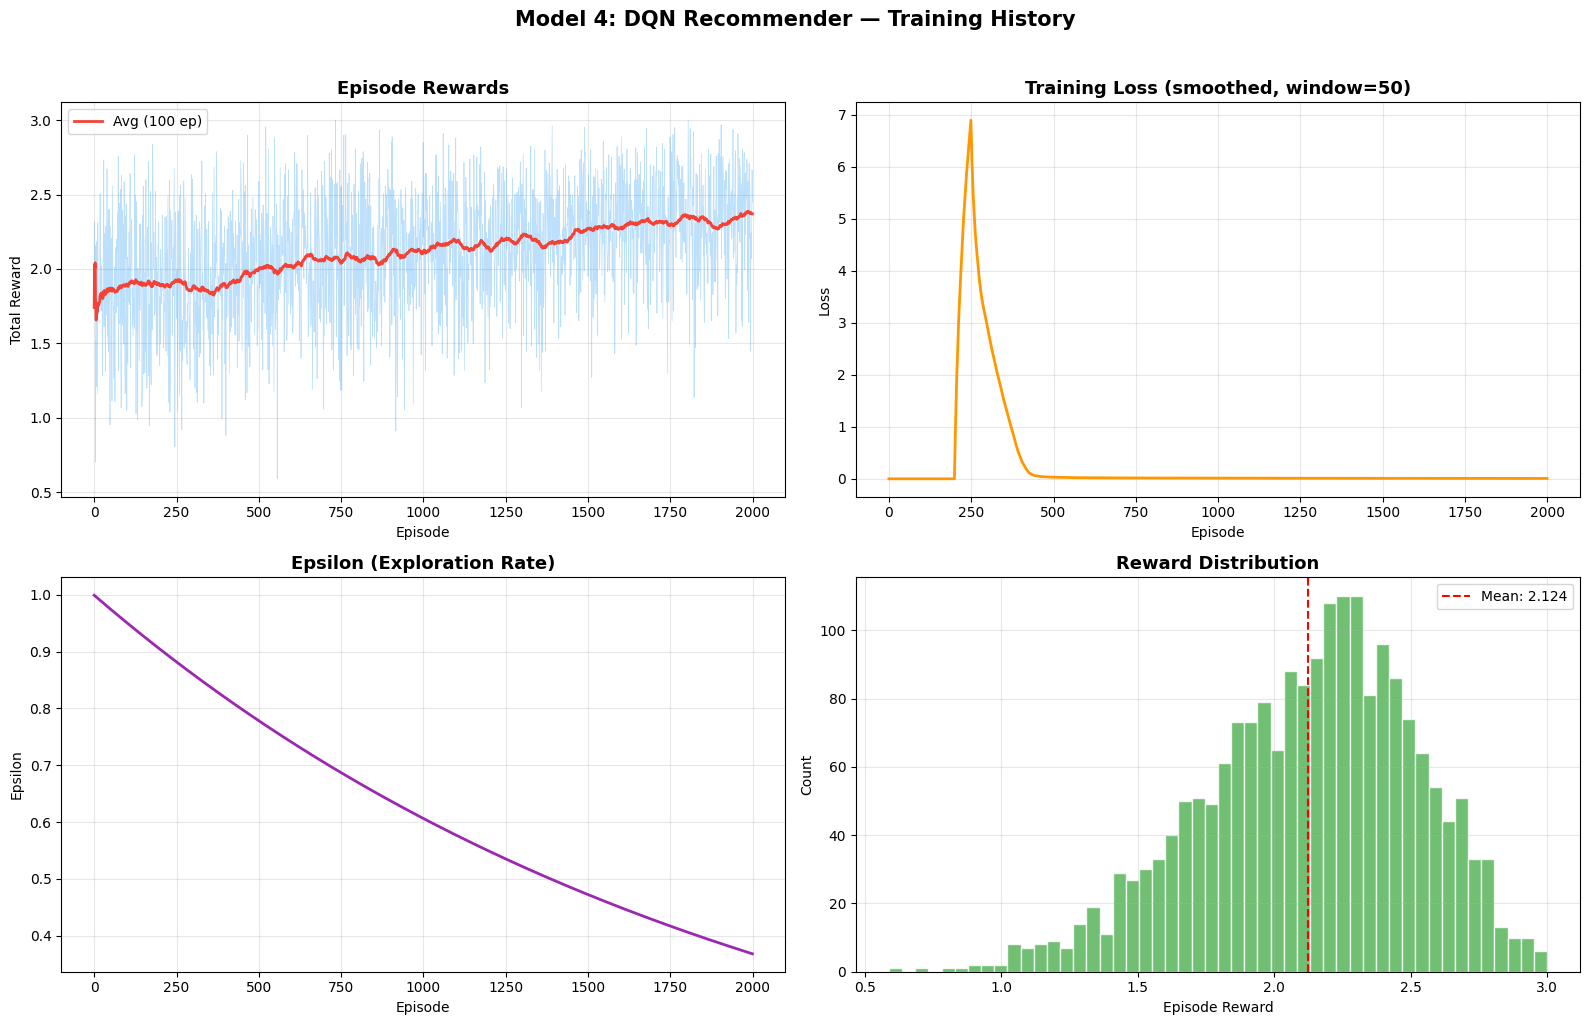

✅ Training plots saved!


In [11]:
# ============================================
# CELL 10: Plot Training History
# ============================================

import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Episode Rewards
axes[0, 0].plot(history['episode_rewards'], alpha=0.3, color='#2196F3', linewidth=0.5)
axes[0, 0].plot(history['avg_rewards_100'], color='#F44336', linewidth=2, label='Avg (100 ep)')
axes[0, 0].set_title('Episode Rewards', fontsize=13, fontweight='bold')
axes[0, 0].set_xlabel('Episode')
axes[0, 0].set_ylabel('Total Reward')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Loss
if history['losses']:
    # Smooth loss
    window = 50
    smoothed_loss = pd.Series(history['losses']).rolling(window=window, min_periods=1).mean()
    axes[0, 1].plot(smoothed_loss, color='#FF9800', linewidth=2)
    axes[0, 1].set_title(f'Training Loss (smoothed, window={window})', fontsize=13, fontweight='bold')
    axes[0, 1].set_xlabel('Episode')
    axes[0, 1].set_ylabel('Loss')
    axes[0, 1].grid(True, alpha=0.3)

# Epsilon Decay
axes[1, 0].plot(history['epsilons'], color='#9C27B0', linewidth=2)
axes[1, 0].set_title('Epsilon (Exploration Rate)', fontsize=13, fontweight='bold')
axes[1, 0].set_xlabel('Episode')
axes[1, 0].set_ylabel('Epsilon')
axes[1, 0].grid(True, alpha=0.3)

# Reward Distribution
axes[1, 1].hist(history['episode_rewards'], bins=50, color='#4CAF50', alpha=0.8, edgecolor='white')
axes[1, 1].axvline(x=np.mean(history['episode_rewards']), color='red',
                    linestyle='--', label=f'Mean: {np.mean(history["episode_rewards"]):.3f}')
axes[1, 1].set_title('Reward Distribution', fontsize=13, fontweight='bold')
axes[1, 1].set_xlabel('Episode Reward')
axes[1, 1].set_ylabel('Count')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.suptitle('Model 4: DQN Recommender — Training History',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'model4_training_history.png'), dpi=150, bbox_inches='tight')
plt.show()
print("✅ Training plots saved!")

Cell 11: Evaluate — Run Full Recommendation

In [13]:
# ============================================
# CELL 11: Full Recommendation Evaluation
# ============================================

# Load best model
checkpoint = torch.load(
    os.path.join(MODELS_DIR, 'dqn_recommender_best.pth'),
    weights_only=False
)
policy_net.load_state_dict(checkpoint['policy_state_dict'])
policy_net.eval()

print(f"📥 Loaded best DQN from Episode {checkpoint['episode']}")
print(f"   Best Avg Reward: {checkpoint['best_avg_reward']:.4f}")

def recommend_accessories(dress_info, occasion, religion, gender, budget, top_k=3):
    """
    FULL RECOMMENDATION FUNCTION

    Takes dress attributes + user context → Returns Top-K accessories
    """
    # Generate fused vector (simulating Model 3 output)
    fused_vector = np.zeros(256, dtype=np.float32)

    dress_colors = dress_encoders['color']['classes']
    if dress_info.get('color', '') in dress_colors:
        fused_vector[dress_colors.index(dress_info['color'])] = 1.0

    if occasion in OCCASIONS:
        fused_vector[20 + OCCASIONS.index(occasion)] = 1.0

    seasons_list = dress_encoders['season']['classes']
    if dress_info.get('season', '') in seasons_list:
        fused_vector[30 + seasons_list.index(dress_info['season'])] = 1.0

    if gender in GENDERS:
        fused_vector[34 + GENDERS.index(gender)] = 1.0

    fused_vector[37] = budget / BUDGET_MAX
    fused_vector[40:] = np.random.randn(216).astype(np.float32) * 0.05

    # Reset environment
    state = env.reset(
        fused_vector=fused_vector,
        dress_info=dress_info,
        occasion=occasion,
        religion=religion,
        gender=gender,
        budget=budget
    )

    recommendations = []

    for step in range(top_k):
        action_mask = env.get_action_mask()

        # Use policy network (no exploration)
        with torch.no_grad():
            state_tensor = torch.tensor(state, dtype=torch.float32).unsqueeze(0).to(device)
            q_values = policy_net(state_tensor, wardrobe_device)

            mask_tensor = torch.tensor(action_mask, dtype=torch.float32).to(device)
            q_values = q_values + (mask_tensor - 1) * 1e9

            action = q_values.argmax(dim=1).item()
            q_value = q_values[0, action].item()

        next_state, reward, done, info = env.step(action)

        recommendations.append({
            'rank': step + 1,
            'accessory': info['accessory'],
            'q_value': round(q_value, 4),
            'reward': round(reward, 4),
        })

        state = next_state

    return recommendations

# ============ TEST WITH SCENARIOS ============
test_scenarios = [
    {
        'name': '🎉 Red Silk Saree �� Wedding',
        'dress': {'color': 'Red', 'pattern': 'Solid', 'fabric': 'Silk',
                  'neckline': 'V-Neck', 'dress_length': 'Maxi',
                  'sleeve_length': 'Short Sleeve', 'usage': 'Formal', 'season': 'Summer'},
        'occasion': 'Wedding', 'religion': 'Buddhist', 'gender': 'Women', 'budget': 15000
    },
    {
        'name': '💼 Blue Formal Shirt → Office',
        'dress': {'color': 'Blue', 'pattern': 'Solid', 'fabric': 'Cotton',
                  'neckline': 'Collared', 'dress_length': 'Mini',
                  'sleeve_length': 'Long Sleeve', 'usage': 'Formal', 'season': 'Fall'},
        'occasion': 'Office', 'religion': 'None', 'gender': 'Men', 'budget': 5000
    },
    {
        'name': '🎊 Black Party Dress → Night Out',
        'dress': {'color': 'Black', 'pattern': 'Solid', 'fabric': 'Satin',
                  'neckline': 'Off-Shoulder', 'dress_length': 'Midi',
                  'sleeve_length': 'Sleeveless', 'usage': 'Party', 'season': 'Winter'},
        'occasion': 'Party', 'religion': 'None', 'gender': 'Women', 'budget': 12000
    },
    {
        'name': '👕 White Casual T-Shirt → Beach',
        'dress': {'color': 'White', 'pattern': 'Striped', 'fabric': 'Cotton',
                  'neckline': 'Crew Neck', 'dress_length': 'Mini',
                  'sleeve_length': 'Short Sleeve', 'usage': 'Casual', 'season': 'Summer'},
        'occasion': 'Beach', 'religion': 'None', 'gender': 'Women', 'budget': 3000
    },
    {
        'name': '🛕 Gold Kurta → Temple Visit',
        'dress': {'color': 'Yellow', 'pattern': 'Solid', 'fabric': 'Silk',
                  'neckline': 'High Neck', 'dress_length': 'Midi',
                  'sleeve_length': '3/4 Sleeve', 'usage': 'Festive/Religious', 'season': 'Spring'},
        'occasion': 'Festive/Religious', 'religion': 'Hindu', 'gender': 'Women', 'budget': 10000
    },
]

print("=" * 70)
print("🔮 ACCESSORY RECOMMENDATIONS")
print("=" * 70)

for scenario in test_scenarios:
    recs = recommend_accessories(
        scenario['dress'], scenario['occasion'],
        scenario['religion'], scenario['gender'], scenario['budget']
    )

    print(f"\n{'─'*70}")
    print(f"{scenario['name']}")
    print(f"   Dress: {scenario['dress']['color']} {scenario['dress']['pattern']} {scenario['dress']['fabric']}")
    print(f"   Context: {scenario['occasion']} | {scenario['religion']} | {scenario['gender']} | Rs.{scenario['budget']}")
    print(f"   ─────────────────────────────")

    total_reward = 0
    for rec in recs:
        acc = rec['accessory']
        total_reward += rec['reward']
        emoji_map = {
            'Watches': '⌚', 'Earrings': '💎', 'Necklaces & Chains': '📿',
            'Bracelets & Bangles': '💫', 'Rings': '💍', 'Belts': '🔗',
            'Sunglasses & Eyewear': '🕶️', 'Handbags & Clutches': '👜',
            'Hats & Headwear': '🎩', 'Scarves & Shawls': '🧣',
            'Ties & Bowties': '👔', 'Cufflinks': '🔘', 'Hair Accessories': '🎀'
        }
        emoji = emoji_map.get(acc['category'], '📦')
        print(f"   #{rec['rank']} {emoji} {acc['category']} ({acc['color']}) — Q: {rec['q_value']:.2f} | Reward: {rec['reward']:.4f}")
        print(f"       Gender: {acc['gender']} | Season: {acc['season']} | Usage: {acc['usage']}")

    print(f"   ─────────────────────────────")
    print(f"   📊 Total Reward: {total_reward:.4f}")

📥 Loaded best DQN from Episode 1988
   Best Avg Reward: 2.3868
🔮 ACCESSORY RECOMMENDATIONS

──────────────────────────────────────────────────────────────────────
🎉 Red Silk Saree �� Wedding
   Dress: Red Solid Silk
   Context: Wedding | Buddhist | Women | Rs.15000
   ─────────────────────────────
   #1 💫 Bracelets & Bangles (Gold) — Q: 2.51 | Reward: 0.7765
       Gender: Women | Season: Fall | Usage: Casual
   #2 👔 Ties & Bowties (Gold) — Q: 1.73 | Reward: 0.8577
       Gender: Men | Season: Summer | Usage: Formal
   #3 💍 Rings (Silver) — Q: 0.82 | Reward: 0.9273
       Gender: Women | Season: Summer | Usage: Casual
   ─────────────────────────────
   📊 Total Reward: 2.5615

──────────────────────────────────────────────────────────────────────
💼 Blue Formal Shirt → Office
   Dress: Blue Solid Cotton
   Context: Office | None | Men | Rs.5000
   ─────────────────────────────
   #1 💫 Bracelets & Bangles (Gold) — Q: 2.78 | Reward: 0.8421
       Gender: Women | Season: Fall | Usage: Casu

Cell 12: Evaluate Recommendation Quality

📊 RECOMMENDATION QUALITY EVALUATION


Evaluating: 100%|██████████| 500/500 [00:13<00:00, 37.37it/s]



📊 Results over 500 random scenarios:
   Avg Total Reward:     2.4914 ± 0.1794
   Avg Diversity Score:  100.0%
   Avg Color Match Rate: 84.8%
   Avg Occasion Match:   66.7%


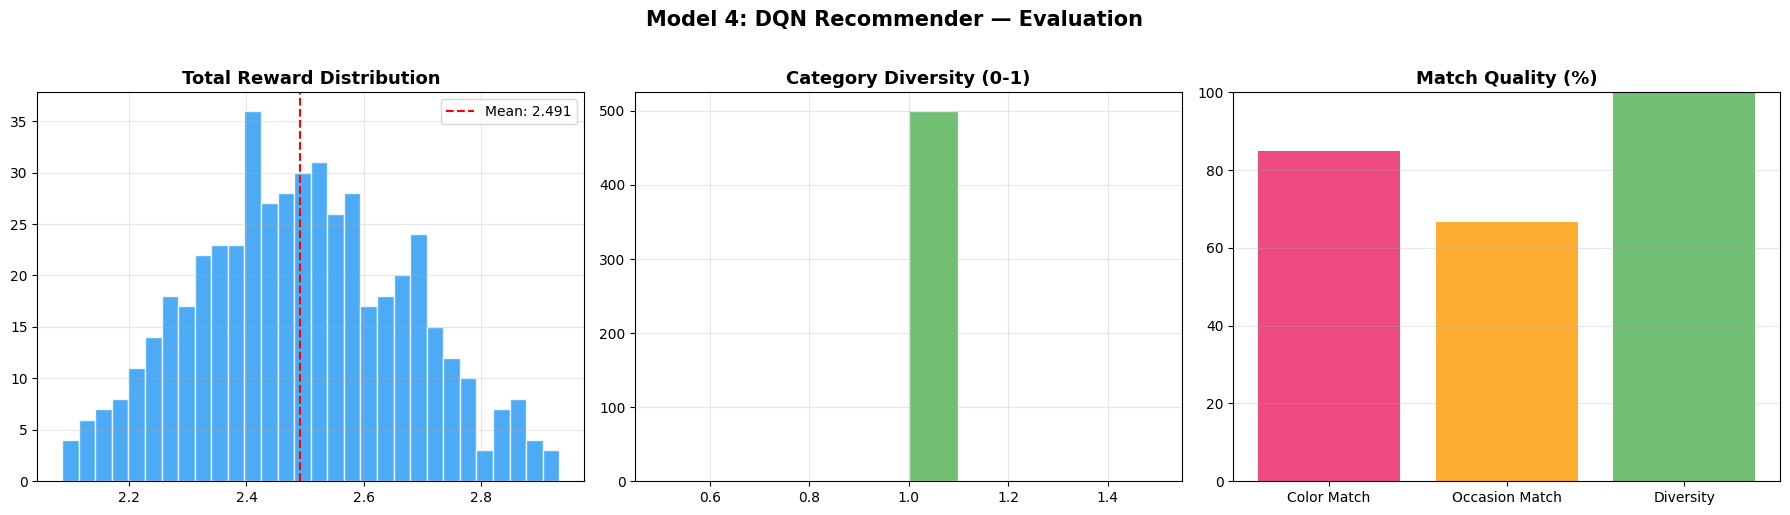


✅ Evaluation complete!


In [14]:
# ============================================
# CELL 12: Evaluate Recommendation Quality
# ============================================

print("=" * 70)
print("📊 RECOMMENDATION QUALITY EVALUATION")
print("=" * 70)

# Run 500 random scenarios and measure quality
NUM_EVAL = 500
eval_rewards = []
eval_diversity = []
eval_color_match = []
eval_occasion_match = []

for _ in tqdm(range(NUM_EVAL), desc="Evaluating"):
    fv, di, occ, rel, gen, bud = generate_random_scenario()

    recs = recommend_accessories(di, occ, rel, gen, bud, top_k=3)

    # Total reward
    total_reward = sum(r['reward'] for r in recs)
    eval_rewards.append(total_reward)

    # Diversity: unique categories in top 3
    categories = set(r['accessory']['category'] for r in recs)
    eval_diversity.append(len(categories) / 3.0)

    # Color match rate
    dress_color = di.get('color', 'Multi-color')
    compat_colors = COLOR_COMPAT.get(dress_color, [])
    color_matches = sum(1 for r in recs if r['accessory']['color'] in compat_colors)
    eval_color_match.append(color_matches / 3.0)

    # Occasion match rate
    compat_usages = OCCASION_COMPAT.get(occ, ['Casual'])
    occ_matches = sum(1 for r in recs if r['accessory']['usage'] in compat_usages)
    eval_occasion_match.append(occ_matches / 3.0)

print(f"\n📊 Results over {NUM_EVAL} random scenarios:")
print(f"   Avg Total Reward:     {np.mean(eval_rewards):.4f} ± {np.std(eval_rewards):.4f}")
print(f"   Avg Diversity Score:  {np.mean(eval_diversity)*100:.1f}%")
print(f"   Avg Color Match Rate: {np.mean(eval_color_match)*100:.1f}%")
print(f"   Avg Occasion Match:   {np.mean(eval_occasion_match)*100:.1f}%")

# Plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(eval_rewards, bins=30, color='#2196F3', alpha=0.8, edgecolor='white')
axes[0].axvline(x=np.mean(eval_rewards), color='red', linestyle='--', label=f'Mean: {np.mean(eval_rewards):.3f}')
axes[0].set_title('Total Reward Distribution', fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].hist(eval_diversity, bins=10, color='#4CAF50', alpha=0.8, edgecolor='white')
axes[1].set_title('Category Diversity (0-1)', fontsize=13, fontweight='bold')
axes[1].grid(True, alpha=0.3)

axes[2].bar(['Color Match', 'Occasion Match', 'Diversity'],
            [np.mean(eval_color_match)*100, np.mean(eval_occasion_match)*100, np.mean(eval_diversity)*100],
            color=['#E91E63', '#FF9800', '#4CAF50'], alpha=0.8)
axes[2].set_title('Match Quality (%)', fontsize=13, fontweight='bold')
axes[2].set_ylim(0, 100)
axes[2].grid(True, alpha=0.3, axis='y')

plt.suptitle('Model 4: DQN Recommender — Evaluation',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'model4_evaluation.png'), dpi=150, bbox_inches='tight')
plt.show()
print("\n✅ Evaluation complete!")

Cell 13: Save Final Model & All Artifacts

In [16]:
# ============================================
# CELL 13: Save Final Model & All Artifacts
# ============================================

import pickle

# Load best model
#checkpoint = torch.load(os.path.join(MODELS_DIR, 'dqn_recommender_best.pth'))
checkpoint = torch.load(
    os.path.join(MODELS_DIR, 'dqn_recommender_best.pth'),
    weights_only=False
)

policy_net.load_state_dict(checkpoint['policy_state_dict'])

# ============ SAVE INFERENCE MODEL ============
inference_save = {
    'policy_state_dict': policy_net.state_dict(),
    'state_dim': STATE_DIM,
    'query_dim': QUERY_DIM,
    'accessory_dim': ACCESSORY_DIM,
    'wardrobe_tensor': wardrobe_tensor,
    'wardrobe_metadata': wardrobe_metadata,
    'accessory_categories': ACCESSORY_CATEGORIES,
    'occasions': OCCASIONS,
    'religions': RELIGIONS,
    'genders': GENDERS,
    'budget_min': BUDGET_MIN,
    'budget_max': BUDGET_MAX,
}

torch.save(inference_save, os.path.join(MODELS_DIR, 'dqn_recommender_inference.pth'))

# ============ SAVE MODEL INFO ============
model_info = {
    'model_name': 'DuelingDQN_AccessoryRecommender',
    'architecture': 'Dueling DQN with Dot-Product Action Scoring',
    'input': {
        'state_dim': STATE_DIM,
        'fused_vector_dim': 256,
        'accessory_dim': ACCESSORY_DIM,
    },
    'output': {
        'top_k': 3,
        'q_values': f'{WARDROBE_SIZE} accessories',
    },
    'dqn_config': {
        'query_dim': QUERY_DIM,
        'gamma': GAMMA,
        'epsilon_start': EPSILON_START,
        'epsilon_end': EPSILON_END,
        'epsilon_decay': EPSILON_DECAY,
        'buffer_size': BUFFER_SIZE,
        'batch_size': BATCH_SIZE,
        'target_update': TARGET_UPDATE,
    },
    'wardrobe': {
        'total_accessories': WARDROBE_SIZE,
        'categories': ACCESSORY_CATEGORIES,
        'feature_dim': ACCESSORY_DIM,
    },
    'best_episode': checkpoint['episode'],
    'best_avg_reward': round(checkpoint['best_avg_reward'], 4),
    'evaluation': {
        'avg_total_reward': round(float(np.mean(eval_rewards)), 4),
        'avg_diversity': round(float(np.mean(eval_diversity)), 4),
        'avg_color_match': round(float(np.mean(eval_color_match)), 4),
        'avg_occasion_match': round(float(np.mean(eval_occasion_match)), 4),
    },
    'training_config': {
        'total_episodes': NUM_EPISODES,
        'warmup_episodes': WARMUP_EPISODES,
        'learning_rate': LR,
        'optimizer': 'Adam',
        'loss': 'SmoothL1 (Huber)',
    },
}

with open(os.path.join(MODELS_DIR, 'model4_info.json'), 'w') as f:
    json.dump(model_info, f, indent=2)

# Save training history
with open(os.path.join(MODELS_DIR, 'model4_history.pkl'), 'wb') as f:
    pickle.dump(history, f)

# ============ LIST ALL FILES ============
print("=" * 60)
print("📁 ALL SAVED FILES — COMPLETE PROJECT")
print("=" * 60)

total_size = 0
for folder_name, folder_path in [('trained_models', MODELS_DIR), ('data', DATA_DIR), ('plots', PLOTS_DIR)]:
    print(f"\n📂 {folder_path}/")
    for f_name in sorted(os.listdir(folder_path)):
        size = os.path.getsize(os.path.join(folder_path, f_name))
        total_size += size
        if size > 1024 * 1024:
            print(f"   📄 {f_name} ({size / (1024*1024):.1f} MB)")
        else:
            print(f"   📄 {f_name} ({size / 1024:.1f} KB)")

print(f"\n📊 Total Storage: {total_size / (1024*1024):.1f} MB")

📁 ALL SAVED FILES — COMPLETE PROJECT

📂 /content/drive/MyDrive/AccessoriesAI/trained_models/
   📄 accessory_classifier_resnet152_best.pth (702.2 MB)
   📄 accessory_classifier_resnet152_inference.pth (234.5 MB)
   📄 accessory_label_encoders.json (0.9 KB)
   📄 dqn_recommender_best.pth (6.6 MB)
   📄 dqn_recommender_inference.pth (3.8 MB)
   📄 dress_attribute_extractor_best.pth (706.0 MB)
   📄 dress_attribute_extractor_inference.pth (235.8 MB)
   📄 dress_label_encoders.json (1.9 KB)
   📄 fusion_metadata_schema.json (0.4 KB)
   📄 fusion_transformer_best.pth (6.1 MB)
   📄 fusion_transformer_inference.pth (2.0 MB)
   📄 model1_history.pkl (2.2 KB)
   📄 model1_info.json (1.8 KB)
   📄 model2_history.pkl (0.2 KB)
   📄 model2_info.json (3.1 KB)
   📄 model3_history.pkl (3.6 KB)
   📄 model3_info.json (1.3 KB)
   📄 model4_history.pkl (109.6 KB)
   📄 model4_info.json (1.2 KB)

📂 /content/drive/MyDrive/AccessoriesAI/data/
   📄 accessories_balanced.csv (1.2 MB)
   📄 accessories_raw_clean.csv (979.4 KB)


Cell 14: Final End-to-End Test

In [17]:
# ============================================
# CELL 14: Final End-to-End Pipeline Test
# ============================================

import random

def full_pipeline_recommend(dress_info, occasion, religion, gender, budget):
    """
    COMPLETE END-TO-END RECOMMENDATION PIPELINE

    In production:
    1. User uploads dress image → Model 2 extracts attributes
    2. Model 3 fuses dress attrs + user metadata → 256-dim vector
    3. Model 4 (DQN) recommends Top 3 accessories

    Here we simulate steps 1-2 and run step 3.
    """
    # Step 3: DQN recommendation
    recs = recommend_accessories(dress_info, occasion, religion, gender, budget, top_k=3)
    return recs

# ============ BEAUTIFUL FINAL TEST ============
print("=" * 70)
print("🎯 COMPLETE SYSTEM — END-TO-END ACCESSORY RECOMMENDATION")
print("=" * 70)

final_tests = [
    {
        'scenario': '👰 Sri Lankan Wedding Guest',
        'dress': {'color': 'Red', 'pattern': 'Solid', 'fabric': 'Silk',
                  'neckline': 'Sweetheart', 'dress_length': 'Floor-length',
                  'sleeve_length': 'Sleeveless', 'usage': 'Formal', 'season': 'Summer'},
        'occasion': 'Wedding', 'religion': 'Buddhist', 'gender': 'Women', 'budget': 20000
    },
    {
        'scenario': '👨‍💼 Corporate Interview',
        'dress': {'color': 'Navy Blue', 'pattern': 'Solid', 'fabric': 'Cotton',
                  'neckline': 'Collared', 'dress_length': 'Mini',
                  'sleeve_length': 'Long Sleeve', 'usage': 'Formal', 'season': 'Fall'},
        'occasion': 'Interview', 'religion': 'None', 'gender': 'Men', 'budget': 8000
    },
    {
        'scenario': '💃 Saturday Night Party',
        'dress': {'color': 'Black', 'pattern': 'Solid', 'fabric': 'Satin',
                  'neckline': 'Off-Shoulder', 'dress_length': 'Midi',
                  'sleeve_length': 'Sleeveless', 'usage': 'Party', 'season': 'Winter'},
        'occasion': 'Party', 'religion': 'None', 'gender': 'Women', 'budget': 15000
    },
]

for test in final_tests:
    recs = full_pipeline_recommend(
        test['dress'], test['occasion'], test['religion'],
        test['gender'], test['budget']
    )

    print(f"\n{'━'*70}")
    print(f"  {test['scenario']}")
    print(f"{'━'*70}")
    print(f"  👗 Dress: {test['dress']['color']} {test['dress']['pattern']} {test['dress']['fabric']}")
    print(f"     Neckline: {test['dress']['neckline']} | Length: {test['dress']['dress_length']}")
    print(f"  🎯 Occasion: {test['occasion']} | 🛕 Religion: {test['religion']}")
    print(f"  👤 Gender: {test['gender']} | 💰 Budget: Rs.{test['budget']:,}")
    print(f"  {'─'*66}")
    print(f"  🎁 RECOMMENDED ACCESSORIES:")

    total_reward = 0
    for rec in recs:
        acc = rec['accessory']
        total_reward += rec['reward']
        emoji_map = {
            'Watches': '⌚', 'Earrings': '💎', 'Necklaces & Chains': '📿',
            'Bracelets & Bangles': '💫', 'Rings': '💍', 'Belts': '🔗',
            'Sunglasses & Eyewear': '🕶️', 'Handbags & Clutches': '👜',
            'Hats & Headwear': '🎩', 'Scarves & Shawls': '🧣',
            'Ties & Bowties': '👔', 'Cufflinks': '🔘', 'Hair Accessories': '🎀'
        }
        emoji = emoji_map.get(acc['category'], '📦')
        print(f"     #{rec['rank']} {emoji} {acc['category']}")
        print(f"        Color: {acc['color']} | Gender: {acc['gender']}")
        print(f"        Season: {acc['season']} | Usage: {acc['usage']}")
        print(f"        Match Score: {rec['reward']:.4f}")

    print(f"  {'─'*66}")
    print(f"  📊 Total Match Score: {total_reward:.4f}")

print(f"\n{'='*70}")
print(f"🎉🎉🎉 ALL 4 MODELS TRAINING COMPLETE! 🎉🎉🎉")
print(f"{'='*70}")
print(f"""
📋 COMPLETE MODEL SUMMARY:
{'─'*70}
Model 1: Accessory Classifier (ResNet-152)
   → Classifies accessories into 13 categories
   → Predicts: category, color, gender, season, usage

Model 2: Dress Attribute Extractor (ResNet-152)
   → Extracts 9 dress attributes from image
   → Predicts: color, neckline, length, fabric, pattern, sleeve, usage, season, gender

Model 3: Multimodal Fusion Transformer
   → Fuses dress features + user metadata
   → Output: 256-dim fused vector + compatibility score

Model 4: DQN Accessory Recommender
   → Recommends Top 3 matching accessories
   → Uses reinforcement learning with diversity rewards
{'─'*70}

📁 All models saved to: {MODELS_DIR}
🚀 Ready for Flask backend integration!
""")

🎯 COMPLETE SYSTEM — END-TO-END ACCESSORY RECOMMENDATION

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  👰 Sri Lankan Wedding Guest
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  👗 Dress: Red Solid Silk
     Neckline: Sweetheart | Length: Floor-length
  🎯 Occasion: Wedding | 🛕 Religion: Buddhist
  👤 Gender: Women | 💰 Budget: Rs.20,000
  ──────────────────────────────────────────────────────────────────
  🎁 RECOMMENDED ACCESSORIES:
     #1 💫 Bracelets & Bangles
        Color: Gold | Gender: Women
        Season: Fall | Usage: Casual
        Match Score: 0.8086
     #2 👔 Ties & Bowties
        Color: Gold | Gender: Men
        Season: Summer | Usage: Formal
        Match Score: 0.8831
     #3 💍 Rings
        Color: Silver | Gender: Women
        Season: Summer | Usage: Casual
        Match Score: 0.9554
  ──────────────────────────────────────────────────────────────────
  📊 Total Match Score: 2.6471

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━